# Una ballena muere. Su cuerpo cae 6 kilómetros. Y empieza a alimentar vida durante millones de años.

Durante décadas, en todos los océanos del mundo, se habían encontrado apenas un puñado de estos funerales submarinos. Hasta que un barco rastreó una franja del Índico y encontró **486 restos de ballena** regados a lo largo de ~1.200 km de fondo marino. Algunos llevan ahí **5,3 millones de años**.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** *A 5.3-million-year-old deep-sea whale necropolis in the Diamantina Zone* — Peng et al., **Nature** (2026)  
**DOI:** [10.1038/s41586-026-10546-z](https://doi.org/10.1038/s41586-026-10546-z)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-06-10-necropolis-ballenas-diamantina/notebook.ipynb)

**Video:** [Ver en YouTube](https://youtube.com/shorts/nCmyGzQPqgY)

## Qué es esto

Cuando una ballena muere, su cuerpo se hunde hasta el fondo del mar. Allí, en un desierto sin luz ni comida, ese cadáver se vuelve un oasis: durante años da de comer a gusanos, estrellas y bacterias. Los biólogos lo llaman *whale fall* (caída de ballena).

El equipo bajó 24 veces en un sumergible tripulado a la **Zona Diamantina** (océano Índico suroriental) y registró **486 restos de ballena georreferenciados** entre los 4.616 y los 7.001 metros de profundidad. Vamos a abrir esos datos.

> Es un estudio **observacional**: describe lo que encontraron, no manipula nada. Las cifras son conteos y posiciones, no efectos de un experimento.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
PROF_REFERENCIA = 6000       # Umbral de profundidad (m) que separa abisal de casi-hadal
COLOR_DATOS = '#2563EB'      # Azul CaM — restos de ballena
COLOR_ALERTA = '#DC2626'     # Rojo — umbral / valor de contraste
COLOR_REFERENCIA = '#D97706' # Ámbar — referencia
FUENTE = 'Fuente: Peng et al. (2026), Nature | Datos: Supplementary Tables 1-2'

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Estilo CaM (local -> fallback GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/papers/2026-06-10-necropolis-ballenas-diamantina'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Descarga automática de datos si faltan (Colab)
os.makedirs('datos', exist_ok=True)
for archivo in ['whale_observations.csv', 'comunidad_por_taxon.csv']:
    ruta = f'datos/{archivo}'
    if not os.path.exists(ruta):
        urllib.request.urlretrieve(f'{BASE}/datos/{archivo}', ruta)

# Carga
obs = pd.read_csv('datos/whale_observations.csv')
com = pd.read_csv('datos/comunidad_por_taxon.csv')

# Profundidad limpia (1 registro sin dato)
prof = pd.to_numeric(obs['depth_m'], errors='coerce').dropna()

print(f'Restos de ballena registrados : {len(obs)}')
print(f'Profundidad                   : {prof.min():.0f} – {prof.max():.0f} m')
print(f'Profundidad mediana           : {prof.median():.0f} m')
print(f'Taxones en las comunidades    : {len(com)}  ({com["phylum"].nunique()} filos)')

Restos de ballena registrados : 486
Profundidad                   : 4616 – 7001 m
Profundidad mediana           : 6527 m
Taxones en las comunidades    : 20  (5 filos)


## El mapa de un cementerio

Cada punto es los restos de una ballena. Aquí están.

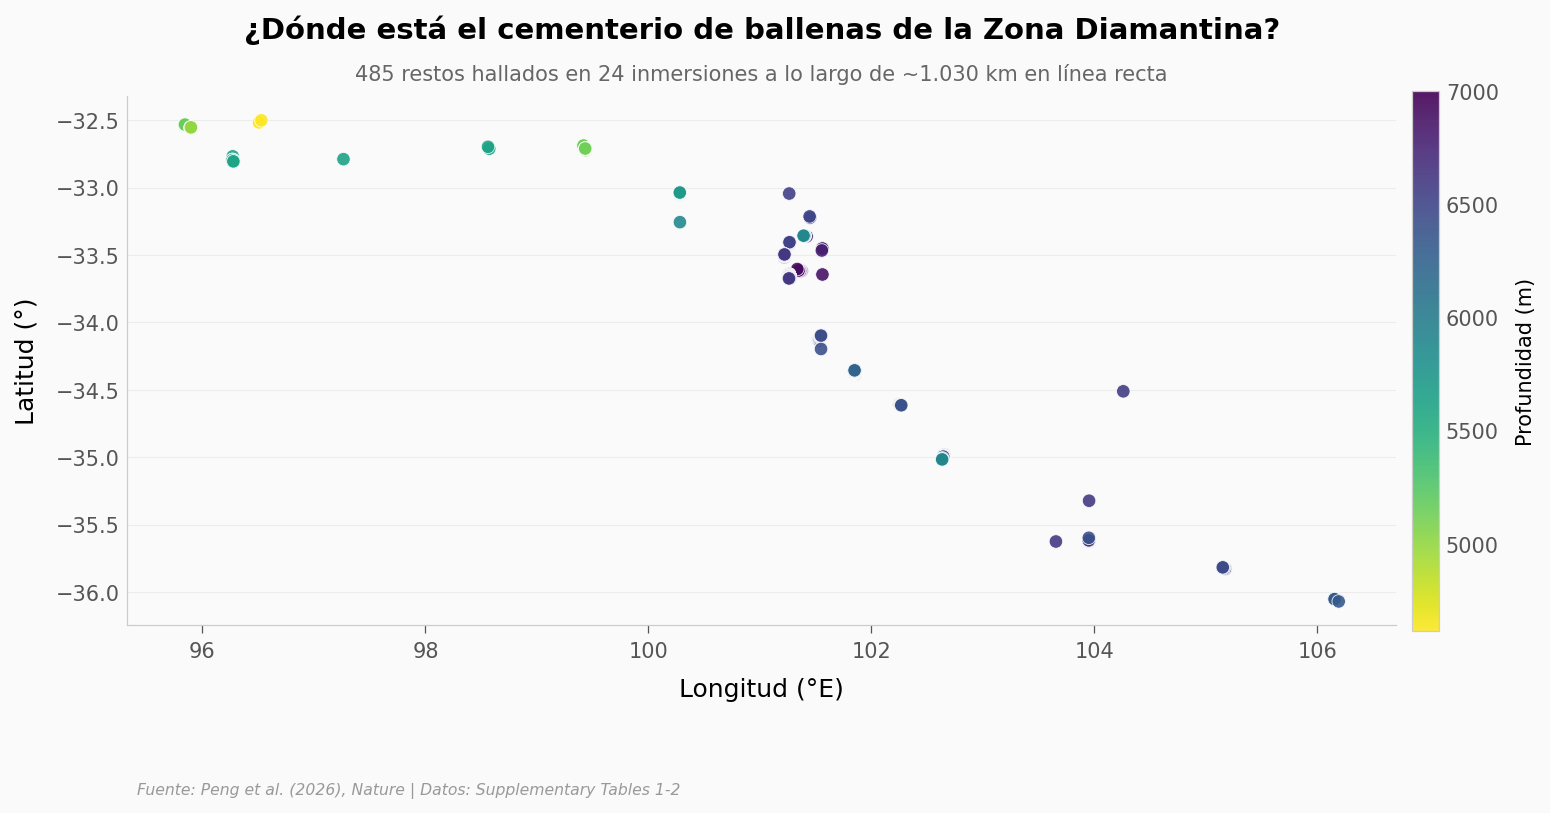

Extensión en longitud: 10.3° de longitud
Distancia oeste–este (línea recta): 1028 km


In [2]:
# Mapa: cada punto = restos de una ballena, color = profundidad
geo = obs.dropna(subset=['longitude_deg', 'latitude_deg']).copy()
geo['depth_m'] = pd.to_numeric(geo['depth_m'], errors='coerce')

fig, ax = plt.subplots(figsize=(13, 5.5))
sc = ax.scatter(geo['longitude_deg'], geo['latitude_deg'],
                c=geo['depth_m'], cmap='viridis_r', s=42,
                edgecolors='white', linewidths=0.4, alpha=0.9, zorder=5)

# Proporción geográfica correcta (1 grado de lon < 1 grado de lat en estas latitudes)
lat_med = geo['latitude_deg'].mean()
ax.set_aspect(1 / np.cos(np.deg2rad(lat_med)))

cbar = plt.colorbar(sc, ax=ax, shrink=0.85, pad=0.01)
cbar.set_label('Profundidad (m)', fontsize=10)

ax.set_title('¿Dónde está el cementerio de ballenas de la Zona Diamantina?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, '485 restos hallados en 24 inmersiones a lo largo de ~1.030 km en línea recta',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Longitud (°E)')
ax.set_ylabel('Latitud (°)')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/mapa_necropolis.png', dpi=200, bbox_inches='tight')
plt.show()

# Distancia en línea recta (gran círculo) entre los dos extremos de longitud
def gran_circulo_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi, dlmb = np.radians(lat2 - lat1), np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dlmb/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

oeste = geo.loc[geo['longitude_deg'].idxmin()]
este = geo.loc[geo['longitude_deg'].idxmax()]
extremo_km = gran_circulo_km(oeste['latitude_deg'], oeste['longitude_deg'],
                             este['latitude_deg'], este['longitude_deg'])
span_lon = geo['longitude_deg'].max() - geo['longitude_deg'].min()
print(f'Extensión en longitud: {span_lon:.1f}° de longitud')
print(f'Distancia oeste–este (línea recta): {extremo_km:.0f} km')

## Lo que llama la atención

Los restos no están regados al azar: se concentran en un corredor estrecho que cruza el fondo del océano de oeste a este. En línea recta entre los extremos hay ~1.030 km; siguiendo el trazado del fondo, el paper reporta cerca de **1.200 km** de acumulación.

Y casi todo está hondo. El color más oscuro domina el mapa: la mayoría de estas ballenas descansan por debajo de los 6 kilómetros. Veamos exactamente cuánto.

## No todas las ballenas están igual de muertas

Un cadáver de ballena pasa por etapas a medida que el tiempo lo consume. Los datos clasifican cada resto según en qué etapa quedó congelado:

- **Caída sin fosilizar** — el cadáver aún tiene tejido, recién llegado.
- **Etapa sulfofílica** — bacterias que comen azufre dominan; el oasis químico está activo.
- **Etapa de arrecife** — quedan los huesos, ahora superficie dura para que se peguen otros animales.
- **Fósil de ballena** — el hueso ya es roca; lleva muchísimo tiempo ahí.

¿Cómo se reparten los 486 restos entre estas etapas?

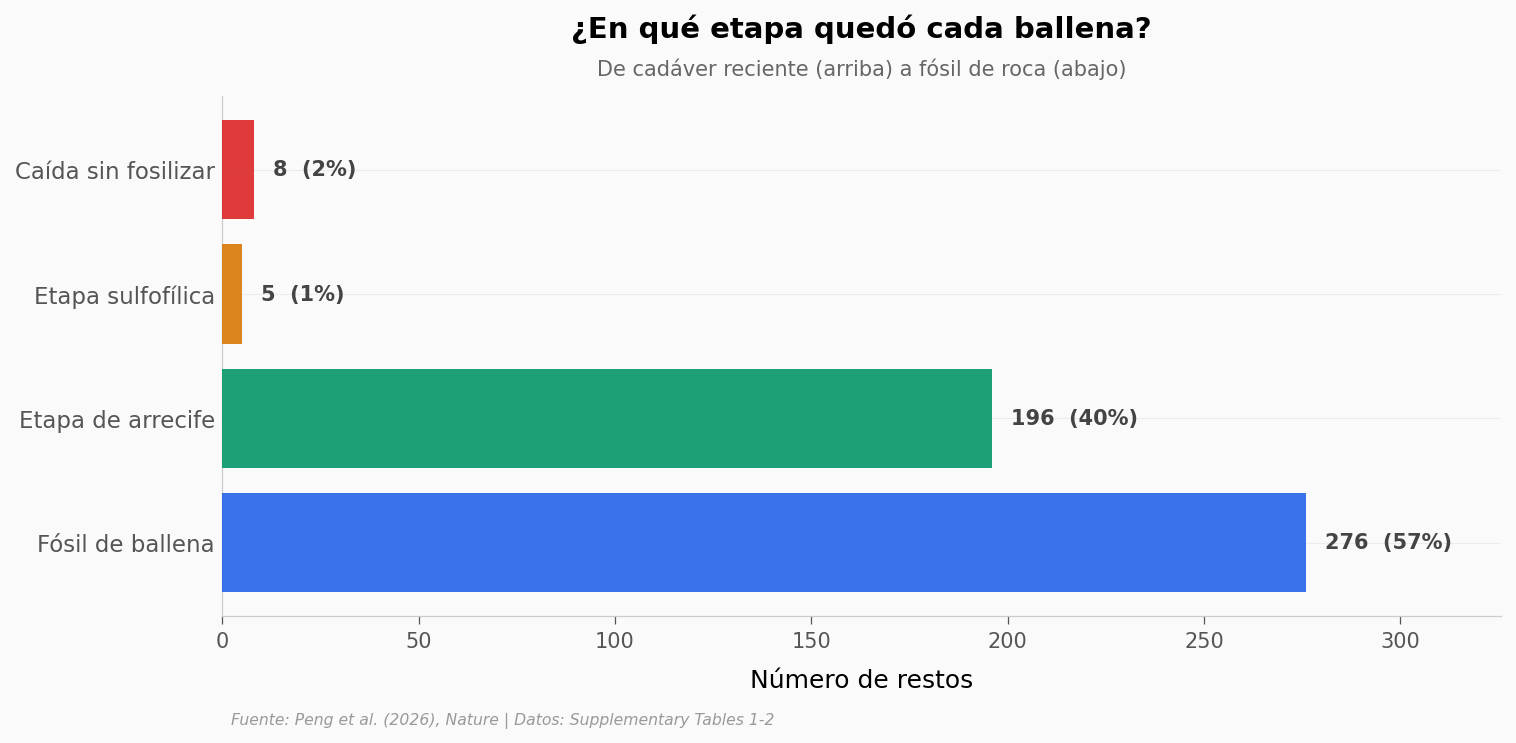

In [3]:
# Composición por etapa ecológica (el reloj del cementerio)
orden = ['Unfossilized whale fall', 'Sulfophilic stage', 'Reef stage', 'Whale fossil']
etiquetas = ['Caída sin fosilizar', 'Etapa sulfofílica', 'Etapa de arrecife', 'Fósil de ballena']
conteos = [int((obs['stage'] == s).sum()) for s in orden]
colores = ['#DC2626', '#D97706', '#059669', '#2563EB']

fig, ax = plt.subplots(figsize=(11, 4.5))
barras = ax.barh(range(len(orden)), conteos, color=colores, alpha=0.9, zorder=5)
ax.set_yticks(range(len(orden)))
ax.set_yticklabels(etiquetas, fontsize=11)
ax.invert_yaxis()  # reciente arriba, fósil abajo (orden temporal)

total = sum(conteos)
for i, c in enumerate(conteos):
    ax.text(c + total*0.01, i, f'{c}  ({c/total*100:.0f}%)',
            va='center', fontsize=10, fontweight='bold', color='#444444')

ax.set_xlim(0, max(conteos) * 1.18)
ax.set_title('¿En qué etapa quedó cada ballena?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.04, 'De cadáver reciente (arriba) a fósil de roca (abajo)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Número de restos')

fig.text(0.13, -0.05, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/etapas.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Quién vive de una ballena muerta?

Las etapas activas (sin fosilizar, sulfofílica, arrecife) hospedan comunidades enteras. El equipo contó **2.355 individuos** repartidos en **20 taxones** y **5 grandes grupos animales**. ¿Quién manda?

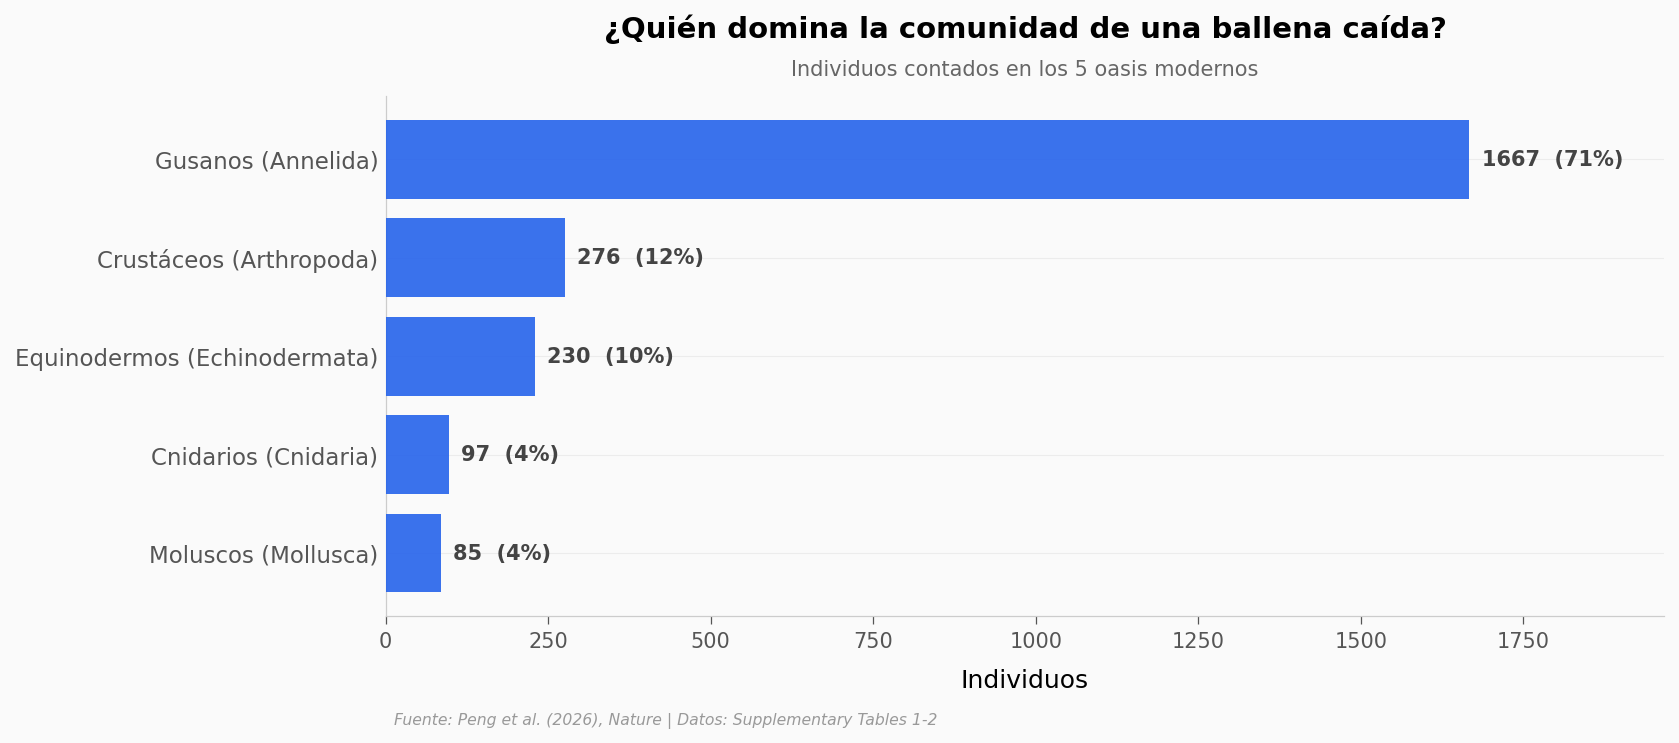

Solo de gusanos come-huesos (Osedax sp. 1) se contaron 588 individuos.


In [4]:
# Composición de la comunidad por filo (¿quién domina en número?)
por_filo = com.groupby('phylum')['total_individuals'].sum().sort_values()
nombres_es = {
    'Annelida': 'Gusanos (Annelida)',
    'Arthropoda': 'Crustáceos (Arthropoda)',
    'Echinodermata': 'Equinodermos (Echinodermata)',
    'Cnidaria': 'Cnidarios (Cnidaria)',
    'Mollusca': 'Moluscos (Mollusca)',
}
etiquetas = [nombres_es.get(p, p) for p in por_filo.index]
total = por_filo.sum()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.barh(range(len(por_filo)), por_filo.values, color=COLOR_DATOS, alpha=0.9, zorder=5)
ax.set_yticks(range(len(por_filo)))
ax.set_yticklabels(etiquetas, fontsize=11)
for i, v in enumerate(por_filo.values):
    ax.text(v + total*0.008, i, f'{int(v)}  ({v/total*100:.0f}%)',
            va='center', fontsize=10, fontweight='bold', color='#444444')
ax.set_xlim(0, por_filo.max() * 1.18)
ax.set_title('¿Quién domina la comunidad de una ballena caída?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.04, 'Individuos contados en los 5 oasis modernos',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Individuos')

fig.text(0.13, -0.05, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/comunidad_filo.png', dpi=200, bbox_inches='tight')
plt.show()

osedax = int(com.loc[com['common_name'] == 'bone-eating worm 1', 'total_individuals'].sum())
print(f'Solo de gusanos come-huesos (Osedax sp. 1) se contaron {osedax} individuos.')

## El detalle que cuesta creer: qué tan hondo está todo esto

Los gusanos dominan por número, pero el paper subraya a otros como los **especialistas** característicos: estrellas frágiles (ofiuras), gusanos que perforan hueso y almejas que viven de química, no de comida. Característico no es lo mismo que numeroso.

Pero hay un número que pone todo en perspectiva: la **profundidad**. Veamos dónde cae cada resto.

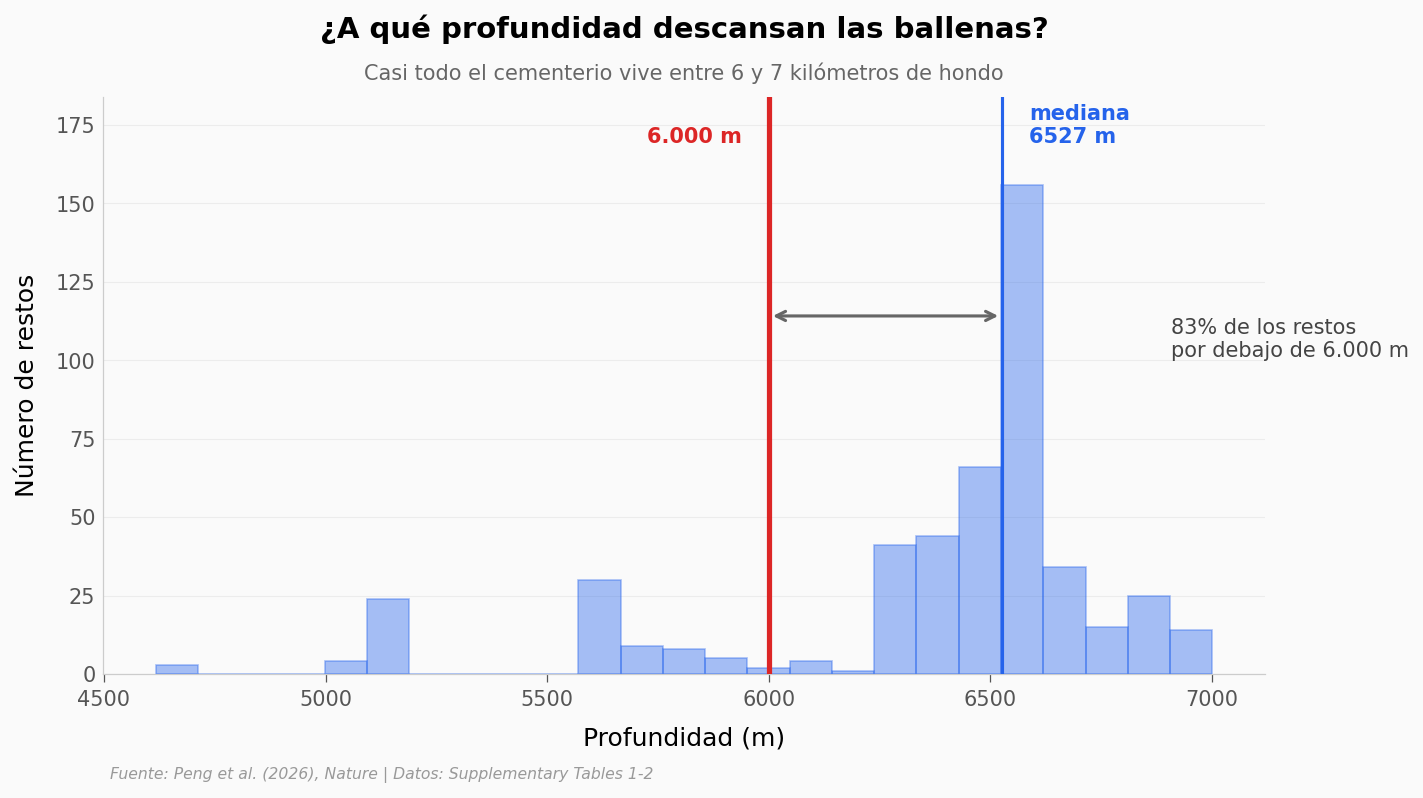

In [5]:
# Distribución de profundidad — ¿qué tan hondo está el cementerio?
fig, ax = plt.subplots(figsize=(10, 5))
n, bins, patches = ax.hist(prof, bins=25, color=COLOR_DATOS, alpha=0.4,
                           edgecolor=COLOR_DATOS, linewidth=0.8, zorder=4)
y_max = n.max() * 1.18
ax.set_ylim(0, y_max)

mediana = prof.median()
ax.axvline(x=mediana, color=COLOR_DATOS, linewidth=1.5, zorder=5)
ax.axvline(x=PROF_REFERENCIA, color=COLOR_ALERTA, linewidth=2.5, zorder=6)

ax.annotate('', xy=(mediana, y_max*0.62), xytext=(PROF_REFERENCIA, y_max*0.62),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))

pct = (prof > PROF_REFERENCIA).mean() * 100
ax.text(PROF_REFERENCIA - 60, y_max*0.92, f'{PROF_REFERENCIA:,} m'.replace(',', '.'),
        color=COLOR_ALERTA, fontweight='bold', fontsize=10, ha='right')
ax.text(mediana + 60, y_max*0.92, f'mediana\n{mediana:.0f} m',
        color=COLOR_DATOS, fontweight='bold', fontsize=10, ha='left')
ax.text(mediana + 380, y_max*0.55, f'{pct:.0f}% de los restos\npor debajo de 6.000 m',
        color='#444444', fontsize=10, ha='left')

ax.set_title('¿A qué profundidad descansan las ballenas?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Casi todo el cementerio vive entre 6 y 7 kilómetros de hondo',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Profundidad (m)')
ax.set_ylabel('Número de restos')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/profundidad_hist.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| 486 restos de ballena registrados en la Zona Diamantina | ✅ | 486 filas georreferenciadas en Supplementary Table 1 (485 con coordenadas completas). |
| Profundidad entre 4.616 y 7.001 m | ✅ | Rango exacto sobre 485 registros con dato; mediana 6.527 m. Coincide con el paper. |
| El 83% de los restos está por debajo de 6.000 m | ✅ | 401/485 registros con profundidad > 6.000 m. Distribución sesgada hacia lo profundo (asimetría −1,6; no normal). |
| Gusanos (Annelida) dominan la comunidad por número | ✅ | 1.667/2.355 individuos (71%), incluidos 588 Osedax come-huesos. Los *especialistas* característicos del paper (ofiuras, perforadores de hueso, bivalvos quimiosintéticos) son otra cosa: característico ≠ numeroso. |
| La mayoría de los restos ya están fosilizados | ✅ | 276/486 en etapa \"fósil de ballena\"; solo 13 son caídas recientes o sulfofílicas. |
| Whale falls en la región desde hace ≥5,3 millones de años | ⚠️ | Lo afirma el paper por datación isotópica; **ese dato no está en esta tabla de datos** — aquí solo tenemos posiciones, profundidad y etapa. |

> **Limitaciones:** (1) La columna de huesos mezcla conteos exactos, valores \"≥\" (ej. `40+`) y texto libre (\"esqueleto casi completo\"), así que **no calculamos un total de huesos**. (2) Las densidades de la Tabla 2 mezclan métodos de muestreo distintos entre oasis y no son comparables, por eso usamos **conteos de individuos**, no densidades. (3) La edad de 5,3 Ma viene del paper (datación isotópica), no de estos archivos. (4) Es un estudio observacional: describe, no prueba causas.

## Ahora tú

Los datos están cargados en `obs` (restos) y `com` (comunidad). Tres preguntas para explorar:

1. **¿El corredor es más hondo hacia el este?** Prueba un scatter de `longitude_deg` contra `depth_m` y mira si la profundidad cambia a lo largo de la franja.
2. **¿Qué taxón aparece en más oasis a la vez?** La columna `n_whalefalls_present` dice en cuántos de los 5 whale-falls se vio cada taxón. Ordena `com` por esa columna.
3. **¿Cambia la mediana de profundidad por etapa?** Agrupa `obs` por `stage` y compara `depth_m` — ¿los fósiles más viejos están más hondo?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 2: ¿qué taxón es más ubicuo (aparece en más oasis)?
ubicuos = com[['taxa', 'phylum', 'total_individuals', 'n_whalefalls_present']] \
    .sort_values('n_whalefalls_present', ascending=False).head(8)
print(ubicuos.to_string(index=False))

# Pista para la pregunta 3 (descomenta):
# prof_etapa = obs.assign(d=pd.to_numeric(obs['depth_m'], errors='coerce')) \
#     .groupby('stage')['d'].median().sort_values()
# print(prof_etapa)

                                                  taxa        phylum  total_individuals  n_whalefalls_present
      Annelida: Maldanidae: Nicomache sp. (tubeworm 1)      Annelida                288                     5
Annelida: Sabellida: Osedax sp. 1 (bone-eating worm 1)      Annelida                588                     4
                     Annelida: Polynoidae (scale worm)      Annelida                 23                     4
                             Mollusca: Gastropoda spp.      Mollusca                 57                     4
                   Cnidaria: Actiniaria: Ostiactis sp.      Cnidaria                 32                     3
Arthropoda: Decapoda: Munidopsis sp. 1 (squat lobster)    Arthropoda                  5                     3
   Echinodermata: Peripodida: Xyloplax sp. (sea daisy) Echinodermata                 21                     2
                            Cnidaria: Actiniaria sp. 2      Cnidaria                 54                     2


## Créditos

- **Paper:** Peng et al. (2026). *A 5.3-million-year-old deep-sea whale necropolis in the Diamantina Zone.* Nature. DOI: [10.1038/s41586-026-10546-z](https://doi.org/10.1038/s41586-026-10546-z)
- **Datos:** Supplementary Tables 1-2 (MOESM3) del mismo artículo · datos originales en Science Data Bank.
- **Licencia datos:** según términos del editor (Springer Nature).
- **Repositorio del notebook:** [Ciencia a Mordiscos / lab](https://github.com/Ciencia-a-Mordiscos/lab)

## Fuentes

**Paper**: [A 5.3-million-year-old deep-sea whale necropolis in the Diamantina Zone](https://doi.org/10.1038/s41586-026-10546-z)  
*Nature, 2026-06-10*

**Supplementary Material**: [Supplementary Tables 1-2 (MOESM3)](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-026-10546-z/MediaObjects/41586_2026_10546_MOESM3_ESM.xlsx) — observaciones y composición faunística (mismo DOI)

**Dataset canónico**: [Science Data Bank](https://doi.org/10.57760/sciencedb.28830) — imágenes in situ y MAGs microbianos

*17 afirmaciones del notebook verificadas contra estas fuentes*